In [1]:
# ----- import dataset -----
# 시작하기에 앞서, 예시로 사용할 MNIST 데이터를 불러온다

In [2]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from tqdm.auto import tqdm

# set dataset
train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

# set data loader
batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

/Users/jeongmoonwon/opt/anaconda3/lib/python3.8/site-packages/torchvision/datasets/mnist.py:498: UserWarning: The given NumPy array is not writeable, and PyTorch does not support non-writeable tensors. This means you can write to the underlying (supposedly non-writeable) NumPy array using the tensor. You may want to copy the array to protect its data or make it writeable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at  ../torch/csrc/utils/tensor_numpy.cpp:180.)
  return torch.from_numpy(parsed.astype(m[2], copy=False)).view(*s)


In [3]:
x, y = next(iter(train_loader))
x.shape, y.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64]))

example data shape:  torch.Size([64, 1, 28, 28])


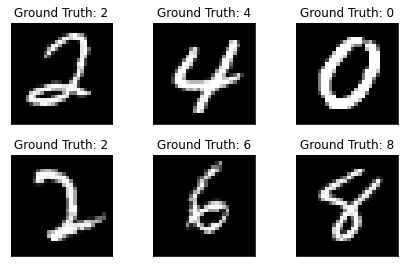

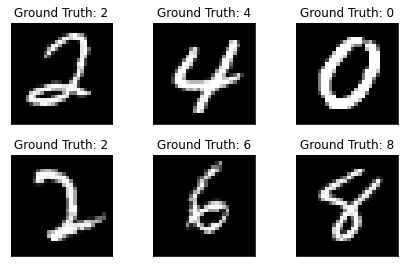

In [4]:
import matplotlib.pyplot as plt

examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)
print("example data shape: ", example_data.shape)

fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Ground Truth: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])
fig

In [5]:
# ----- Define a model -----
# pytorch 모델의 기본 구조 https://anweh.tistory.com/21
# torch.nn layer 종류 https://pytorch.org/docs/stable/nn.html
# 기본 설명 https://velog.io/@gregorioha/2022-국민대학교-겨울-인공지능-특강-4주차-3일-학습-내용

In [6]:
import torch.nn as nn # 신경망을 구축하기 위한 다양한 데이터 구조나 레이어 등이 정의. ex. RNN, LSTM과 같은 레이어, ReLU와 같은 활성화 함수, MSELoss와 같은 손실 함수
import torch.nn.functional as F # torch.nn.functional은 함수고 torch.nn은 클래스로 정의
import torch.optim as optim # 모델을 최적화 하는데 필요한 최적화 함수들 (ex. SGD, ADAM, LBFGS 등등)

class Model(nn.Module): # torch.nn.Module을 상속한다는 뜻
    
    # __init()__에서는 모델에서 사용될 module(nn.Linear, nn.Conv2d), activation function(nn.functional.relu, nn.functional.sigmoid)등을 정의
    # 내가 사용하고 싶은, 내 신경망 모델에 사용될 구성품들을 정의 및 초기화 하는 메소드
    def __init__(self):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(784,128)
        self.fc2 = nn.Linear(128,64)
        self.classifier = nn.Linear(64,10)
        self.batchnorm = nn.BatchNorm1d(64)
    
    # forward()에서는 모델에서 실행되어야하는 계산을 정의
    # backward 계산은 backward()를 이용하면 PyTorch가 알아서 해주니까 forward()만 정의
    # __init__에서 정의된 구성품들을 연결하는 메소드
    def forward(self, x):
        x = x.reshape(-1, 784)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = self.batchnorm(x) # Batch Normalization (fully connected layer뒤, activation function 앞에 사용)
        x = F.relu(x)
        return self.classifier(x)

model = Model()
print(model) # 모델에 대한 정보를 확인

Model(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (classifier): Linear(in_features=64, out_features=10, bias=True)
  (batchnorm): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


In [7]:
# ----- Training a model -----
# batch, epoch 용어 https://bskyvision.com/803

In [8]:
def train(model, optim, loss_fn, train_loader, epochs, device):
    for epoch in range(epochs):
        train_loss = 0.0 
        model.train() # Train 모드로 모델 설정

        for batch in train_loader:
            optim.zero_grad() # gradient를 0으로 initialize
            
            input, target = batch
            # 모델이 존재하는 device에 데이터를 할당 (gpu쓰는 경우)
            input = input.to(device) 
            target = target.to(device) 
            
            output = model(input)
            loss = loss_fn(output, target) # 데이터를 모델에 입력해서 얻은 가설을 output이라는 변수를 만들어 저장하고, 실제값인 ground truth를 target이라는 변수에 저장한 뒤, 손실함수로 둘을 비교
            loss.backward()
            optim.step() # Update learning rate schedule
            train_loss += loss.data.item() 
        train_loss /= len(train_loader.dataset)

        print(f'Epoch: {epoch+1}, Training Loss: {train_loss}')

In [9]:
# tqdm 사용하여 실행시간 측정
def train2(model, optim, loss_fn, train_loader, epochs, device):
    for epoch in range(epochs):
        train_loss = 0.0 
        model.train() # Train 모드로 모델 설정

        tqdm_bar = tqdm(enumerate(train_loader))
        for batch_idx, (input, target) in tqdm_bar:
            optim.zero_grad() # gradient를 0으로 initialize
            
            # 모델이 존재하는 device에 데이터를 할당 (gpu쓰는 경우)
            input = input.to(device) 
            target = target.to(device) 
            
            output = model(input)
            loss = loss_fn(output, target) # 데이터를 모델에 입력해서 얻은 가설을 output이라는 변수를 만들어 저장하고, 실제값인 ground truth를 target이라는 변수에 저장한 뒤, 손실함수로 둘을 비교
            loss.backward()
            optim.step() # Update learning rate schedule
            train_loss += loss.data.item() 
        train_loss /= len(train_loader.dataset)

        print(f'Epoch: {epoch+1}, Training Loss: {train_loss}')

In [10]:
# ----- Testing a model -----
# model.train() vs. model.eval() https://tigris-data-science.tistory.com/entry/PyTorch-modeltrain-vs-modeleval-vs-torchnograd
# 파이썬 with https://pythondocs.net/uncategorized/%ED%8C%8C%EC%9D%B4%EC%8D%AC-with-%EC%A0%95%EB%A6%AC/

In [11]:
def test(model, loss_fn, device):
    model.eval() # 학습할 때와 추론할 때 다르게 동작하는 Layer들을 Evaluation(Inference) mode로 바꿔줌
    test_loss = 0.0
    correct = 0
    
    with torch.no_grad(): # PyTorch의 Autograd Engine을 비활성화하여 Gradient를 계산하지 않도록 함. Gradient를 계산할 필요가 없는 경우 torch.no_grad()를 통해 메모리 사용량을 줄이고 계산 속도를 빠르게 만들 수 있음
        for batch in test_loader:
            input, target = batch
            input = input.to(device)
            target = target.to(device)
            
            output = model(input)
            loss = loss_fn(output, target)
            test_loss += loss.data.item()
            pred = output.data.max(1, keepdim=True)[1] # 모델에 의한 예측
            correct += pred.eq(target.data.view_as(pred)).sum() # 예측값(pred)과 실제값(target)을 비교하여 같은 경우 1을 더함
        test_loss /= len(test_loader.dataset)
    print(f'Test Loss: {test_loss},\t Accuracy: ({100. * correct / len(test_loader.dataset)}%)\n')

In [12]:
# ----- Implement a model -----

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# epoch 수, optimizer, loss_function 정의
num_epochs = 3
optimizer = optim.SGD(model.parameters(), lr=1e-2, momentum=0.9) # momentum은 0보다 큰 실수, GD를 적절한 방향으로 가속화하며, 흔들림(진동)을 줄여주는 매개변수
loss_function = nn.CrossEntropyLoss()

# 모델 훈련 및 테스트 적용
# train(model, optimizer, loss_function, train_loader, num_epochs, device)
train2(model, optimizer, loss_function, train_loader, num_epochs, device)
test(model, loss_function, device)


Epoch: 1, Training Loss: 0.003918637175733844



Epoch: 2, Training Loss: 0.001575457436653475



Epoch: 3, Training Loss: 0.00113331928603972
Test Loss: 0.0011881033260375262,	 Accuracy: (97.58999633789062%)



In [6]:
# ----- Save and load model info -----

In [9]:
# 첫번째 방법: 모델 파라미터와 구조를 저장
torch.save(model, "./data/first_model")
loaded_model = torch.load("./data/first_model")

print(loaded_model)
print(type(loaded_model))

Model(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (classifier): Linear(in_features=64, out_features=10, bias=True)
)
<class '__main__.Model'>


In [10]:
# 두번째 방법 (추천): 각 레이어의 파라미터를 파이썬 딕셔너리로 저장, 모델 변경이 되어도 사용 가능
torch.save(model.state_dict(), "./data/first_model_dict")
state_dict = torch.load("./data/first_model_dict")
print(type(state_dict))

# 모델 변경
model.add_module("additional_layer", nn.Linear(10,10))
print(*model.modules())

model.load_state_dict(state_dict, strict=False)
# network.load_state_dict(state_dict, strict=True) # Raise Error!
print(model)

model.load_state_dict(state_dict, strict=False)
# network.load_state_dict(state_dict, strict=True) # Raise Error!
print(model)

<class 'collections.OrderedDict'>
Model(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (classifier): Linear(in_features=64, out_features=10, bias=True)
  (additional_layer): Linear(in_features=10, out_features=10, bias=True)
) Linear(in_features=784, out_features=128, bias=True) Linear(in_features=128, out_features=64, bias=True) Linear(in_features=64, out_features=10, bias=True) Linear(in_features=10, out_features=10, bias=True)
Model(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (classifier): Linear(in_features=64, out_features=10, bias=True)
  (additional_layer): Linear(in_features=10, out_features=10, bias=True)
)
Model(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (classifier): Linear(in_features=64, out_features=10, bias=True)
  (additional_laye

In [14]:
# 파이토치로부터 Pre-train된 가중치와 모델을 불러오는 방법도 있다!
# https://pytorch.org/vision/stable/models.html
import torchvision.models as models

resnet18 = models.resnet18(pretrained=True)
print(resnet18)

# 모델 구조가 다른 경우 맞출 수 있다.
num_classes = 10
last_layer_in_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(last_layer_in_features, num_classes)
print(resnet18)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  